# Instrumental Variables

## Overview

Instrumental Variables (IV) estimation identifies causal effects when treatment is endogenous — i.e. when unmeasured confounders affect both treatment and outcome, making OLS biased.

**A valid instrument Z must satisfy:**
1. **Relevance:** Z affects treatment D (testable — F-statistic on first stage)
2. **Independence:** Z is independent of unmeasured confounders (untestable — requires domain argument)
3. **Exclusion restriction:** Z affects the outcome only through D (untestable — requires domain argument)

**IV estimand — Local Average Treatment Effect (LATE):**  
IV estimates the treatment effect for *compliers* — units whose treatment status is changed by the instrument. This is not the ATE for the full population.

**Two-Stage Least Squares (2SLS):**  
Stage 1: regress D on Z (and covariates) → get D̂  
Stage 2: regress Y on D̂ (and covariates)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats

rng = np.random.default_rng(42)
n = 600
# Context: effect of upstream land-use intensity on downstream richness
# Instrument: distance to nearest agricultural supplier
# (distance -> land-use intensity -> richness; distance doesn't directly affect richness)
distance_to_supplier = rng.uniform(1, 50, n)   # instrument Z
unmeasured_confounder = rng.normal(0, 1, n)      # e.g. soil quality
# Stage 1: land-use intensity (D) affected by distance and confounder
land_use = (8 - 0.1*distance_to_supplier
            + 0.8*unmeasured_confounder + rng.normal(0, 1.5, n))
# Outcome: richness affected by land_use (true effect=-1.5) and confounder
true_LATE = -1.5
richness = (25 + true_LATE*land_use
            - 1.2*unmeasured_confounder + rng.normal(0, 2, n))
df = pd.DataFrame({"distance":distance_to_supplier,
                    "land_use":land_use,"richness":richness})
print(f"True LATE: {true_LATE}")
naive = smf.ols("richness ~ land_use", df).fit().params["land_use"]
print(f"Naive OLS: {naive:.4f}  (biased by unmeasured confounder)")

True LATE: -1.5
Naive OLS: -1.7190  (biased by unmeasured confounder)


---
## First Stage: Instrument Relevance

First Stage:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.9261      0.149     53.365      0.000       7.634       8.218
distance      -0.1020      0.005    -19.876      0.000      -0.112      -0.092

First-stage F-statistic: 395.05
  Rule of thumb: F > 10 -> instrument is relevant (not weak)
  Strong instrument


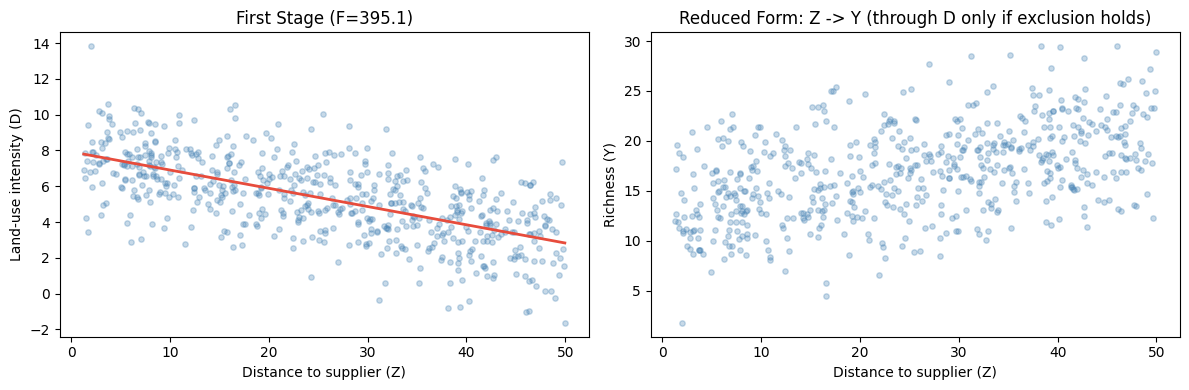

In [2]:
# Stage 1: regress treatment on instrument
stage1 = smf.ols("land_use ~ distance", df).fit()
print("First Stage:")
print(stage1.summary().tables[1])
f_stat = stage1.fvalue
print(f"\nFirst-stage F-statistic: {f_stat:.2f}")
print(f"  Rule of thumb: F > 10 -> instrument is relevant (not weak)")
print(f"  {'Strong instrument' if f_stat > 10 else 'WEAK INSTRUMENT -- IV estimates unreliable'}")
df["land_use_hat"] = stage1.fittedvalues
# Partial correlation plot
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].scatter(df["distance"], df["land_use"], alpha=0.3, s=15, color="steelblue")
axes[0].plot(np.sort(df["distance"]),
             stage1.predict(pd.DataFrame({"distance":np.sort(df["distance"])})),
             color="#e74c3c", lw=2)
axes[0].set_xlabel("Distance to supplier (Z)"); axes[0].set_ylabel("Land-use intensity (D)")
axes[0].set_title(f"First Stage (F={f_stat:.1f})")
axes[1].scatter(df["distance"], df["richness"], alpha=0.3, s=15, color="steelblue")
axes[1].set_xlabel("Distance to supplier (Z)"); axes[1].set_ylabel("Richness (Y)")
axes[1].set_title("Reduced Form: Z -> Y (through D only if exclusion holds)")
plt.tight_layout(); plt.show()

---
## 2SLS Estimation

In [3]:
# Manual 2SLS
stage2 = smf.ols("richness ~ land_use_hat", df).fit()
iv_est_manual = stage2.params["land_use_hat"]
print(f"2SLS estimate (manual):  {iv_est_manual:.4f}")
# Correct 2SLS via statsmodels IV2SLS
from statsmodels.sandbox.regression.gmm import IV2SLS
endog  = df["richness"].values
exog   = sm.add_constant(df["land_use"].values)
instr  = sm.add_constant(df["distance"].values)
iv2sls = IV2SLS(endog, exog, instr).fit()
iv_est = iv2sls.params[1]
iv_se  = iv2sls.bse[1]
iv_ci  = iv2sls.conf_int()[1]
print(f"2SLS estimate (IV2SLS): {iv_est:.4f} (SE={iv_se:.4f})")
print(f"95% CI: [{iv_ci[0]:.4f}, {iv_ci[1]:.4f}]")
print(f"\nTrue LATE: {true_LATE:.4f}")
print(f"Naive OLS: {naive:.4f}  (biased)")
print(f"2SLS:      {iv_est:.4f}  (consistent -- closer to true LATE)")

2SLS estimate (manual):  -1.4990
2SLS estimate (IV2SLS): -1.4990 (SE=0.0662)
95% CI: [-1.6290, -1.3690]

True LATE: -1.5000
Naive OLS: -1.7190  (biased)
2SLS:      -1.4990  (consistent -- closer to true LATE)


---
## Weak Instrument Problem

In [4]:
# Demonstrate: weak instrument -> inflated SE, biased estimate
weak_z = rng.normal(0, 0.3, n)   # nearly useless instrument
land_use_w = (8 + 0.05*weak_z + 0.8*unmeasured_confounder + rng.normal(0,1.5,n))
df_w = pd.DataFrame({"weak_z":weak_z,"land_use_w":land_use_w,"richness":richness})
s1_weak = smf.ols("land_use_w ~ weak_z", df_w).fit()
print(f"Weak instrument F-statistic: {s1_weak.fvalue:.2f}  (should be >> 10)")
df_w["land_use_w_hat"] = s1_weak.fittedvalues
s2_weak = smf.ols("richness ~ land_use_w_hat", df_w).fit()
print(f"Weak IV estimate: {s2_weak.params['land_use_w_hat']:.4f}")
print(f"Strong IV estimate: {iv_est:.4f}")
print(f"True LATE: {true_LATE:.4f}")
print("\nWeak instruments: 2SLS is biased toward OLS, SEs are inflated")
print("Always check F > 10 in the first stage before trusting IV estimates")

Weak instrument F-statistic: 0.49  (should be >> 10)
Weak IV estimate: -4.4776
Strong IV estimate: -1.4990
True LATE: -1.5000

Weak instruments: 2SLS is biased toward OLS, SEs are inflated
Always check F > 10 in the first stage before trusting IV estimates


In [5]:
# Hausman test: is OLS endogenous? (does IV matter?)
# H0: OLS is consistent (no endogeneity)
# Under H0, OLS and 2SLS should give similar estimates
ols_coef = naive
iv_coef  = iv_est
ols_var  = smf.ols("richness ~ land_use", df).fit().cov_params().loc["land_use","land_use"]
iv_var   = iv2sls.cov_params()[1,1]
hausman_stat = (iv_coef - ols_coef)**2 / (iv_var - ols_var)
hausman_p    = 1 - stats.chi2.cdf(hausman_stat, df=1)
print("Hausman endogeneity test:")
print(f"  OLS coef: {ols_coef:.4f}, IV coef: {iv_coef:.4f}")
print(f"  Hausman stat: {hausman_stat:.3f}, p={hausman_p:.4f}")
sig = "Endogeneity present -> use IV" if hausman_p < 0.05 else "No endogeneity -> OLS consistent"
print(f"  {sig}")

Hausman endogeneity test:
  OLS coef: -1.7190, IV coef: -1.4990
  Hausman stat: 17.788, p=0.0000
  Endogeneity present -> use IV


---

## Common Pitfalls

**1. Not checking for a weak instrument**  
A first-stage F-statistic below 10 indicates a weak instrument. 2SLS with a weak instrument is biased toward OLS (negating its purpose) and has severely inflated standard errors. Always report and check the first-stage F before proceeding.

**2. Assuming the exclusion restriction holds without domain justification**  
The exclusion restriction — that the instrument affects the outcome only through the treatment — is untestable from data. It requires a substantive causal argument. Never adopt an instrument purely because it is correlated with treatment; justify the exclusion restriction explicitly.

**3. Interpreting the IV estimate as the ATE for the full population**  
2SLS estimates the LATE — the effect for compliers (units whose treatment status is changed by the instrument). This may be a small and unrepresentative subpopulation. Be precise about the population for which the effect applies.

**4. Using many instruments without testing overidentifying restrictions**  
With multiple instruments, the overidentifying restrictions (Sargan-Hansen test) can partially test instrument validity — if instruments disagree, at least one is invalid. With only one instrument, this test cannot be run.

**5. Manually computing 2SLS and using second-stage standard errors**  
Plugging fitted values from the first stage into OLS and using the resulting SEs produces incorrect (too small) standard errors because the first-stage uncertainty is not propagated. Always use a proper 2SLS implementation (statsmodels IV2SLS, linearmodels) for correct inference.

---
*python_methods_library - Samantha McGarrigle*